## Linear Regression in Python with Scikit-Learn

In [5]:
import pandas as pd

In [17]:
path_to_file = 'Student_score.csv'
df = pd.read_csv(path_to_file)

In [18]:
df.head() 

,Hours,Score
0,1.0,20
1,1.5,22
2,2.0,25
3,2.5,30
4,3.0,35


In [11]:
df.shape

(768, 9)

<Axes: title={'center': 'Scatter Plot of Blood Pressure and Age'}, xlabel='Hours', ylabel='Score'>

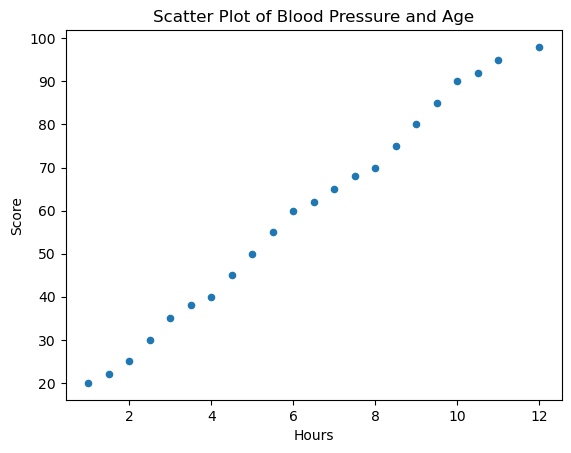

In [19]:
df.plot.scatter(x='Hours', y='Score', title='Scatter Plot of Blood Pressure and Age')

In [20]:
print(df.corr())

          Hours     Score
Hours  1.000000  0.997733
Score  0.997733  1.000000


In [21]:
print(df.describe())

           Hours      Score
count  22.000000  22.000000
mean    6.272727  59.090909
std     3.286796  24.924475
min     1.000000  20.000000
25%     3.625000  38.500000
50%     6.250000  61.000000
75%     8.875000  78.750000
max    12.000000  98.000000


In [22]:
y = df['Hours'].values.reshape(-1, 1)
X = df['Score'].values.reshape(-1, 1)

In [23]:
print(df['Hours'].values) 
print(df['Hours'].values.shape) 

[ 1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5
  8.   8.5  9.   9.5 10.  10.5 11.  12. ]
(22,)


In [24]:
print(X.shape)
print(X)  

(22, 1)
[[20]
 [22]
 [25]
 [30]
 [35]
 [38]
 [40]
 [45]
 [50]
 [55]
 [60]
 [62]
 [65]
 [68]
 [70]
 [75]
 [80]
 [85]
 [90]
 [92]
 [95]
 [98]]


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [26]:
SEED = 42

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = SEED)

In [28]:
print(X_train)
print(y_train)

[[38]
 [95]
 [62]
 [30]
 [35]
 [85]
 [65]
 [90]
 [80]
 [25]
 [55]
 [98]
 [45]
 [60]
 [70]
 [92]
 [40]]
[[ 3.5]
 [11. ]
 [ 6.5]
 [ 2.5]
 [ 3. ]
 [ 9.5]
 [ 7. ]
 [10. ]
 [ 9. ]
 [ 2. ]
 [ 5.5]
 [12. ]
 [ 4.5]
 [ 6. ]
 [ 8. ]
 [10.5]
 [ 4. ]]


In [29]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [30]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
print(regressor.intercept_)

[-1.48039604]


In [32]:
print(regressor.coef_)

[[0.13114247]]


### Making Predictions

In [33]:
def calc(slope, intercept, hours):
    return slope*hours+intercept

score = calc(regressor.coef_, regressor.intercept_, 9.5)
print(score) # [[94.80663482]]

[[-0.23454255]]


In [34]:
score = regressor.predict([[9.5]])
print(score) 

[[-0.23454255]]


In [35]:
y_pred = regressor.predict(X_test)

In [37]:
df_preds = pd.DataFrame({'Actual': y_test.squeeze(), 'Predicted': y_pred.squeeze()})
print(df_preds)

   Actual  Predicted
0     1.0   1.142453
1     7.5   7.437292
2     5.0   5.076728
3     1.5   1.404738
4     8.5   8.355289


### Evaluating the Error

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [40]:
import numpy as np

In [41]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [42]:
print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root mean squared error: {rmse:.2f}')

Mean absolute error: 0.10
Mean squared error: 0.01
Root mean squared error: 0.11


### Multiply Linear Regression

In [43]:
path_to_file = 'petrol_consumption.csv'
df = pd.read_csv(path_to_file)

In [44]:
df.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [45]:
df.shape

(48, 5)

In [46]:
print(df.describe().round(2).T)

                              count     mean      std      min      25%  \
Petrol_tax                     48.0     7.67     0.95     5.00     7.00   
Average_income                 48.0  4241.83   573.62  3063.00  3739.00   
Paved_Highways                 48.0  5565.42  3491.51   431.00  3110.25   
Population_Driver_licence(%)   48.0     0.57     0.06     0.45     0.53   
Petrol_Consumption             48.0   576.77   111.89   344.00   509.50   

                                  50%      75%       max  
Petrol_tax                       7.50     8.12     10.00  
Average_income                4298.00  4578.75   5342.00  
Paved_Highways                4735.50  7156.00  17782.00  
Population_Driver_licence(%)     0.56     0.60      0.72  
Petrol_Consumption             568.50   632.75    968.00  


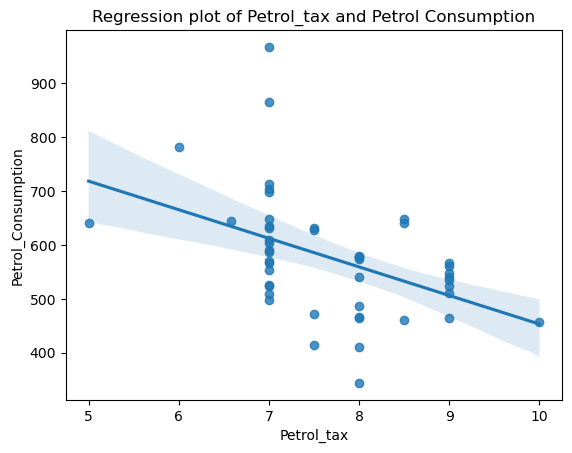

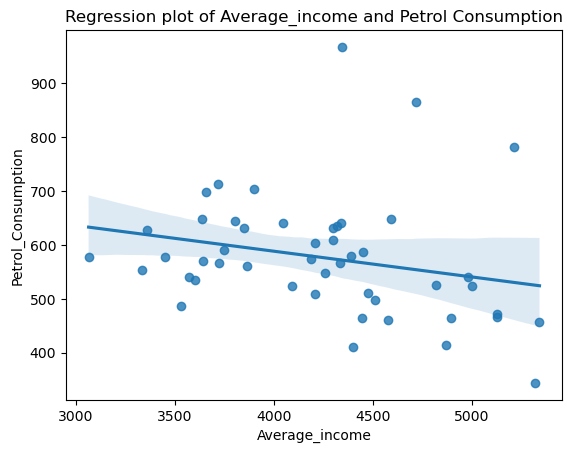

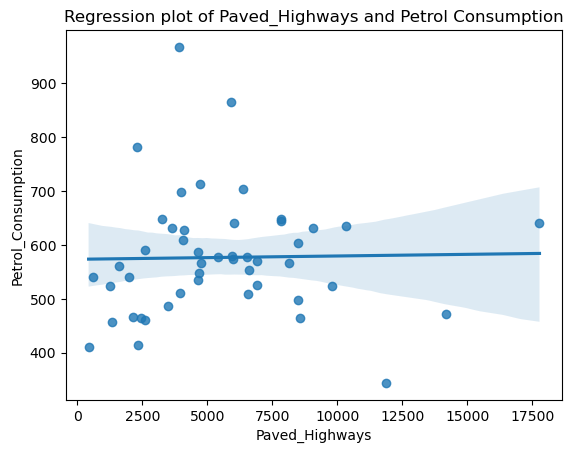

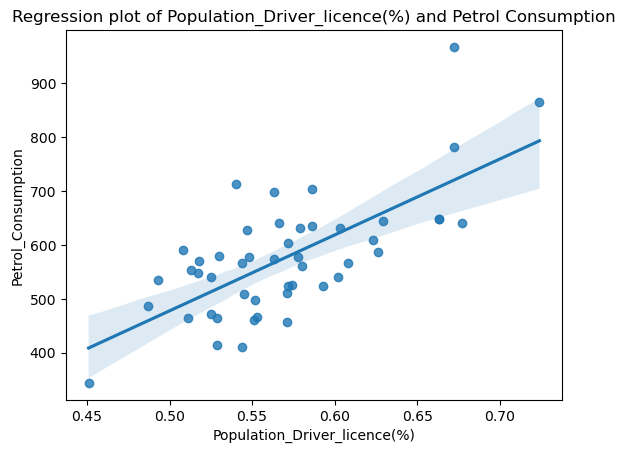

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns # Convention alias for Seaborn

variables = ['Petrol_tax', 'Average_income', 'Paved_Highways','Population_Driver_licence(%)']

for var in variables:
    plt.figure() # Creating a rectangle (figure) for each plot
    # Regression Plot also by default includes
    # best-fitting regression line
    # which can be turned off via `fit_reg=False`
    sns.regplot(x=var, y='Petrol_Consumption', data=df).set(title=f'Regression plot of {var} and Petrol Consumption');

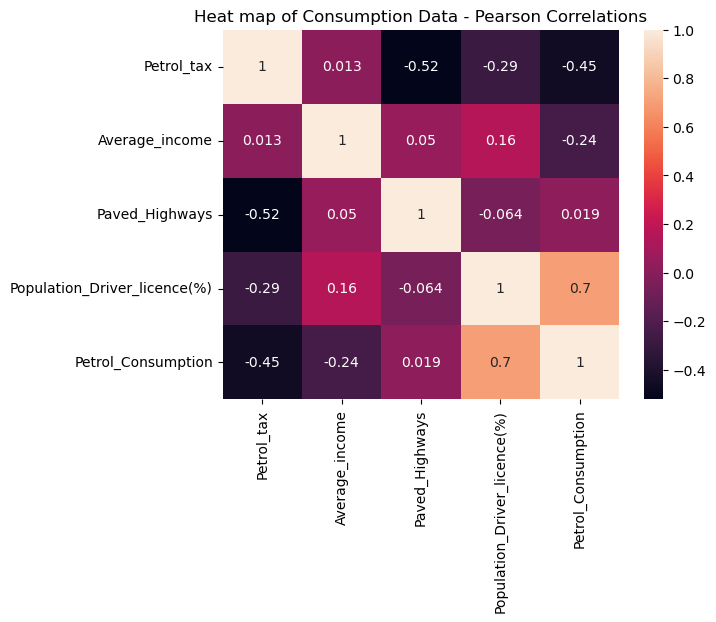

In [49]:
correlations = df.corr()
# annot=True displays the correlation values
sns.heatmap(correlations, annot=True).set(title='Heat map of Consumption Data - Pearson Correlations');

### Preparing the Data

In [50]:
y = df['Petrol_Consumption']
X = df[['Average_income', 'Paved_Highways',
       'Population_Driver_licence(%)', 'Petrol_tax']]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

### Training on multivariate model

In [52]:
X.shape

(48, 4)

In [53]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
regressor.intercept_

np.float64(361.4508790666836)

In [55]:
regressor.coef_

array([-5.65355145e-02, -4.38217137e-03,  1.34686930e+03, -3.69937459e+01])

In [58]:
feature_names = X.columns
print(feature_names)

Index(['Average_income', 'Paved_Highways', 'Population_Driver_licence(%)',
       'Petrol_tax'],
      dtype='object')


In [59]:
feature_names = X.columns
model_coefficients = regressor.coef_

coefficients_df = pd.DataFrame(data = model_coefficients, 
                              index = feature_names, 
                              columns = ['Coefficient value'])
print(coefficients_df)

                              Coefficient value
Average_income                        -0.056536
Paved_Highways                        -0.004382
Population_Driver_licence(%)        1346.869298
Petrol_tax                           -36.993746


### Making Predictions with the Multivariate Regression Model

In [60]:
y_pred = regressor.predict(X_test)

In [61]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)

    Actual   Predicted
27     631  606.692665
40     587  673.779442
26     577  584.991490
43     591  563.536910
24     460  519.058672
37     704  643.461003
12     525  572.897614
19     640  687.077036
4      410  547.609366
25     566  530.037630


### Evaluating the Multivariate Model

In [62]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root mean squared error: {rmse:.2f}')

Mean absolute error: 53.47
Mean squared error: 4083.26
Root mean squared error: 63.90


In [63]:
actual_minus_predicted = sum((y_test - y_pred)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted/actual_minus_actual_mean
print('R²:', r2)

R²: 0.39136640014305457


In [64]:
regressor.score(X_test, y_test)

0.39136640014305457

In [65]:
regressor.score(X_train, y_train)

0.7068781342155135